# ***T20-CRICKET TEAM PERFORMANCE ANALYSIS PROJECT***

---



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

***Data Loading***

In [ ]:
all_datasets = []
all_datasets.append(pd.read_csv("RCB_IPL2024_FirstMatch.csv"))
all_datasets.append(pd.read_csv("RCB_IPL2024_Match2_vs_PBKS.csv"))
all_datasets.append(pd.read_csv("RCB_IPL2024_Match3_vs_GT.csv"))

df = pd.concat(all_datasets, ignore_index = True)

format_overs = 20
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Match_No            33 non-null     int64  
 1   Player_Name         33 non-null     object 
 2   Role                33 non-null     object 
 3   Batting_Position    33 non-null     int64  
 4   Batting_Start_Over  18 non-null     float64
 5   Out_Over            18 non-null     object 
 6   Balls_Played        18 non-null     float64
 7   Runs_Scored         18 non-null     float64
 8   Overs_Bowled        33 non-null     float64
 9   Runs_Given          16 non-null     float64
 10  Wickets_Taken       16 non-null     float64
dtypes: float64(6), int64(2), object(3)
memory usage: 3.0+ KB
None


***Data Validation***

In [ ]:
def data_validation(df):
  bat_stats = (df["Batting_Start_Over"].isnull() &(df["Out_Over"].notnull() | df["Balls_Played"].notnull() | df["Runs_Scored"].notnull()))

  bat_stats2 = (df["Batting_Start_Over"].notnull() & (df["Out_Over"].isnull()))

  bowl_stats = ((df["Overs_Bowled"].isnull() | df["Overs_Bowled"] == 0) & (df["Runs_Given"].notnull() | df["Wickets_Taken"].notnull()))

  invalid_player = ((df["Player_Name"].isnull()) & ( df["Role"].notnull()| df["Batting_Position"].notnull() | df["Batting_Start_Over"].notnull() | df["Out_Over"].notnull() | df["Balls_Played"].notnull() | df["Runs_Scored"].notnull() | df["Overs_Bowled"].notnull() | df["Runs_Given"].notnull() | df["Wickets_Taken"].notnull()))

  no_match = df["Match_No"].isnull()

  no_position = df["Batting_Position"].isnull()

  if no_match.any():
    invalid_rows = df[no_match]
    print(invalid_rows)
    raise ValueError("Some players don't have Match Number information, can't proceed")

  elif no_position.any():
    invalid_rows = df[no_position]
    print(invalid_rows)
    raise ValueError("Some players don't have Batting Position information, can't proceed")

  elif invalid_player.any():
    invalid_rows = df[invalid_player]
    print(invalid_rows)
    raise ValueError("Some players don't have their name, can't proceed")

  elif (bat_stats.any()) or (bat_stats2.any()):
    invalid_rows = df[bat_stats]
    print(invalid_rows)
    raise ValueError("Invalid data found in batting columns, can't procced")

  elif bowl_stats.any():
    invalid_rows = df[bowl_stats]
    print(invalid_rows)
    raise ValueError("Invalid data found in bowling columns, can't procced")

  print("Dataset passed validation process, we can proceed further")


In [ ]:
try:
  data_validation(df)
except Exception as err :
  print(f"Oops! We got some error as {err}")

Dataset passed validation process, we can proceed further


***Data Cleaning***

In [ ]:
df2 = df.copy()

Handling null values

---



In [ ]:
try :
  df2 = df2.dropna(subset = ["Player_Name"])
  df2["Role"] = df2["Role"].fillna(df2["Role"].mode()[0])
  df2["Batting_Start_Over"] = df2["Batting_Start_Over"].fillna(0)
  df2["Out_Over"] = df2["Out_Over"].fillna(0)
  df2["Balls_Played"] = df2["Balls_Played"].fillna(0)
  df2["Runs_Scored"] = df2["Runs_Scored"].fillna(0)
  df2["Overs_Bowled"] = df2["Overs_Bowled"].fillna(0)
  df2.loc[(df2["Overs_Bowled"]>0.0) & (df2["Runs_Given"].isnull()), "Runs_Given"] = 0
  df2.loc[(df2["Overs_Bowled"]>0.0) & (df2["Wickets_Taken"].isnull()), "Wickets_Taken"] = 0
  df2["Runs_Given"] = df2["Runs_Given"].fillna(0)
  df2["Wickets_Taken"] = df2["Wickets_Taken"].fillna(0)
  df2.info()
except Exception as err :
  print(f"Oops! we got an as exception as {err}")
  print("\n")
  print("Please use Valid Datatypes")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Match_No            33 non-null     int64  
 1   Player_Name         33 non-null     object 
 2   Role                33 non-null     object 
 3   Batting_Position    33 non-null     int64  
 4   Batting_Start_Over  33 non-null     float64
 5   Out_Over            33 non-null     object 
 6   Balls_Played        33 non-null     float64
 7   Runs_Scored         33 non-null     float64
 8   Overs_Bowled        33 non-null     float64
 9   Runs_Given          33 non-null     float64
 10  Wickets_Taken       33 non-null     float64
dtypes: float64(6), int64(2), object(3)
memory usage: 3.0+ KB


***Feature Engineering***

Creating boolean Was_Out column for info of out/ not-out

---



In [ ]:
df2["Was_Out"] = (df2["Batting_Start_Over"] > 0 & (df2["Out_Over"] != "not-out") | (df2["Out_Over"] != "Not-Out") |  (df2["Out_Over"] != "Not Out") | (df2["Out_Over"] != "not out"))

Strike rate Column

---



In [ ]:
df2["Strike_Rate"] = ((df2["Runs_Scored"]/df2["Balls_Played"])*100).round(2)

Economy Rate Column

---



In [ ]:
def economy_calc(df2):
  over = df2["Overs_Bowled"].astype(int)
  balls = (df2["Overs_Bowled"] - over)* 10

  df2["real_over"] = over + (balls/6)
  df2["Economy_Rate"] = 0.0

  df2.loc[df2["real_over"] > 0, "Economy_Rate"] = df2.loc[df2["real_over"] > 0, "Runs_Given"]/df2.loc[df2["real_over"] > 0, "real_over"]
  df2.drop(columns=["real_over"], inplace = True)

  df2["Economy_Rate"] = df2["Economy_Rate"].round(2)

  return df2

df2 = economy_calc(df2)


In [ ]:
df2.head()

,Match_No,Player_Name,Role,Batting_Position,Batting_Start_Over,Out_Over,Balls_Played,Runs_Scored,Overs_Bowled,Runs_Given,Wickets_Taken,Was_Out,Strike_Rate,Economy_Rate
0,1,Virat Kohli,batsman,1,0.1,18.5,59.0,77.0,0.0,0.0,0.0,False,130.51,0.00
1,1,Faf du Plessis,batsman,2,0.1,1.2,7.0,3.0,0.0,0.0,0.0,False,42.86,0.00
2,1,Cameron Green,all-rounder,3,1.2,1.3,5.0,3.0,2.0,19.0,0.0,True,60.00,9.50
3,1,Rajat Patidar,batsman,4,1.3,3.4,18.0,18.0,0.0,0.0,0.0,True,100.00,0.00
4,1,Glenn Maxwell,all-rounder,5,3.4,4.3,5.0,3.0,3.0,29.0,2.0,True,60.00,9.67


***EDA***

Total Runs Scored and Total Wickets Taken in each Match

---



In [ ]:
runs_wickets = df2.groupby("Match_No", as_index = False).agg({"Runs_Scored":"sum", "Wickets_Taken": "sum"}).astype(int)
runs_wickets[["Match_No", "Runs_Scored", "Wickets_Taken"]].style.hide(axis="index")

Match_No,Runs_Scored,Wickets_Taken
1,172,4
2,241,6
3,170,6


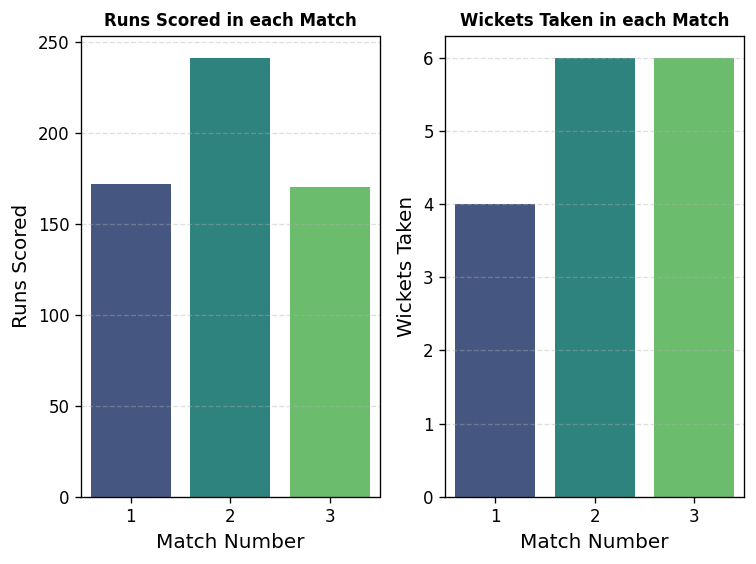

In [ ]:
colors = sns.color_palette("coolwarm", len(runs_wickets))

plt.figure(dpi = 120)
plt.subplot(1,2,1)
sns.barplot(x = runs_wickets["Match_No"], y = runs_wickets["Runs_Scored"], palette = "viridis")

plt.xlabel("Match Number", fontsize = 12)
plt.ylabel("Runs Scored", fontsize = 12)
plt.title("Runs Scored in each Match", fontsize=10, fontweight="bold")

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.subplot(1,2,2)
sns.barplot(x = runs_wickets["Match_No"], y = runs_wickets["Wickets_Taken"], palette = "viridis")

plt.xlabel("Match Number", fontsize = 12)
plt.ylabel("Wickets Taken", fontsize = 12)
plt.title("Wickets Taken in each Match", fontsize=10, fontweight="bold")

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Individual Runs Scored by Players

---



In [ ]:
done_batting = df2[df2["Balls_Played"]> 0]
runs_difference  = done_batting.groupby("Player_Name").agg({"Runs_Scored": "sum", "Balls_Played": "sum"}).sort_values(by = "Runs_Scored", ascending = False).astype(int).reset_index()
runs_difference.index = runs_difference.index + 1
runs_difference[["Player_Name", "Runs_Scored", "Balls_Played"]]

,Player_Name,Runs_Scored,Balls_Played
1,Virat Kohli,239,150
2,Will Jacks,112,48
3,Rajat Patidar,73,41
4,Cameron Green,49,32
5,Dinesh Karthik,43,24
6,Mahipal Lomror,32,19
7,Faf du Plessis,12,14
8,Anuj Rawat,11,4
9,Saurav Chauhan,9,6
10,Glenn Maxwell,3,5


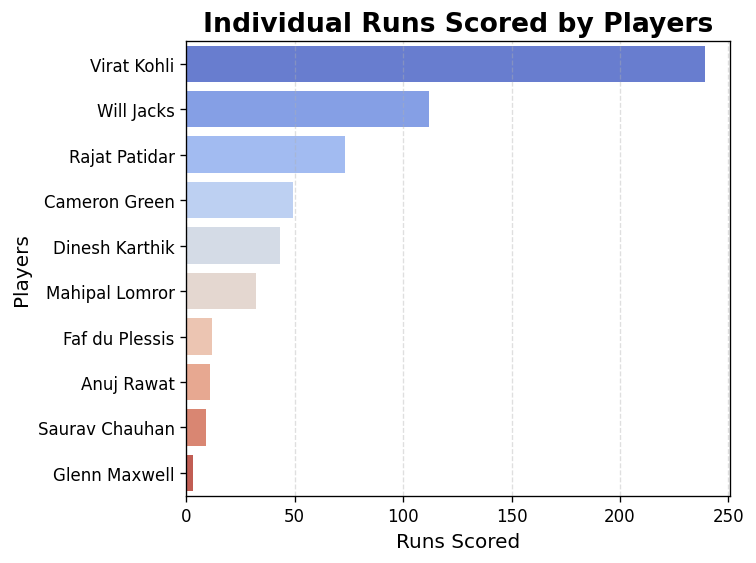

In [ ]:
colors = sns.color_palette("coolwarm", len(runs_difference))

# Horizontal barplot
plt.figure(dpi = 120)
sns.barplot(y=runs_difference["Player_Name"], x=runs_difference["Runs_Scored"], palette=colors)

# Titles and labels
plt.title("Individual Runs Scored by Players", fontsize=16, fontweight="bold")
plt.xlabel("Runs Scored", fontsize=12)
plt.ylabel("Players", fontsize=12)

# Gridlines
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Total Runs Contribution

---



In [ ]:
top_batters = runs_difference[["Player_Name", "Runs_Scored"]].head()
other_runs = runs_difference["Runs_Scored"].sum().astype(int) - top_batters["Runs_Scored"].sum().astype(int)
batting_data = top_batters.copy()
batting_data.loc[len(batting_data)] = ["Others", int(other_runs)]
batting_data = batting_data[batting_data["Runs_Scored"] > 0]

In [ ]:
batting_data

,Player_Name,Runs_Scored
1,Virat Kohli,239
2,Will Jacks,112
3,Rajat Patidar,73
4,Cameron Green,49
5,Others,67


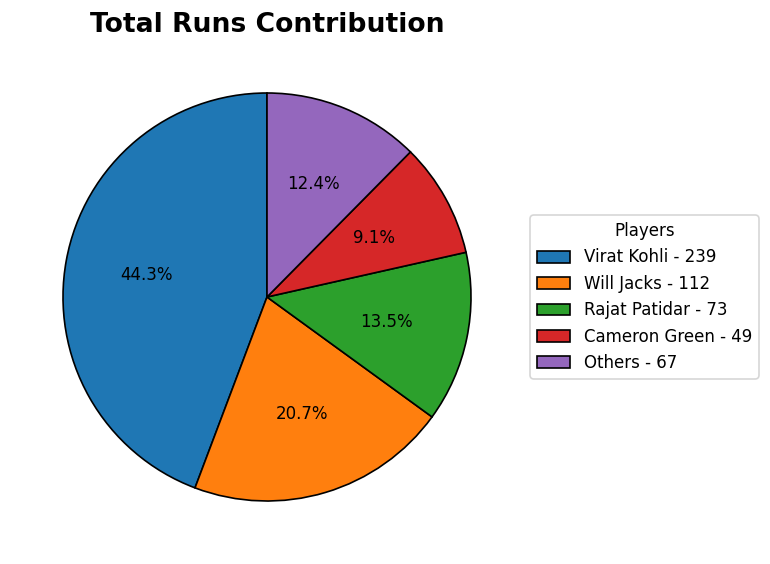

In [ ]:
plt.figure(dpi = 120)
wedges, texts, autotexts = plt.pie(batting_data["Runs_Scored"], labels= None, autopct="%1.1f%%", startangle=90, wedgeprops={"edgecolor": "black"})

# Create legend labels with values
legend_labels = [
    f"{player} - {runs}"
    for player, runs in zip(batting_data["Player_Name"], batting_data["Runs_Scored"])
]

plt.legend(wedges, legend_labels, title="Players", loc="center left", bbox_to_anchor=(1, 0.5))

plt.title("Total Runs Contribution", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


Individual Wickets Taken by Players

---



In [ ]:
done_bowling = df2[df2["Overs_Bowled"]> 0]
bowling_diff = (done_bowling.groupby("Player_Name", as_index = False).agg({"Wickets_Taken": "sum", "Overs_Bowled" : "sum"})).sort_values(by = "Wickets_Taken",ascending = False).reset_index(drop = True)
bowling_diff["Wickets_Taken"] = bowling_diff["Wickets_Taken"].astype(int)
bowling_diff.index = bowling_diff.index + 1
bowling_diff

,Player_Name,Wickets_Taken,Overs_Bowled
1,Yash Dayal,6,12.0
2,Swapnil Singh,4,8.0
3,Cameron Green,3,9.0
4,Glenn Maxwell,2,3.0
5,Karn Sharma,1,8.0
6,Lockie Ferguson,0,1.0
7,Mohammed Siraj,0,12.0
8,Will Jacks,0,2.0


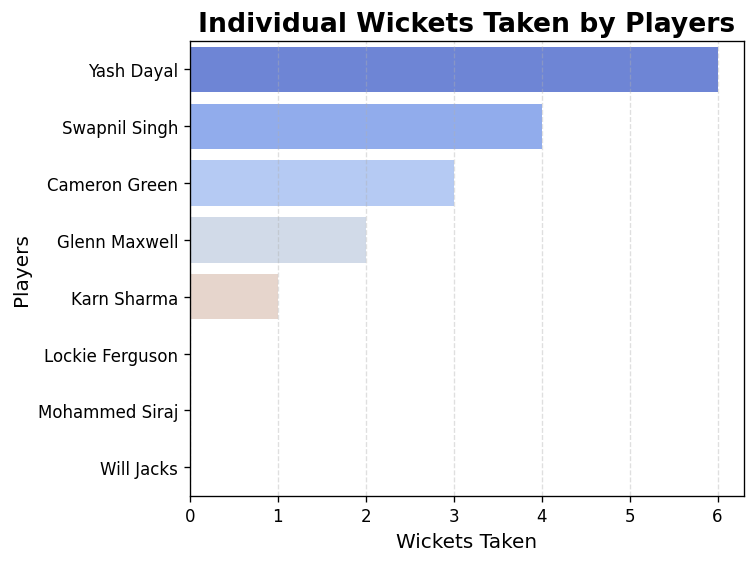

In [ ]:
colors = sns.color_palette("coolwarm", len(bowling_diff))

# Horizontal Barplot

plt.figure(dpi = 120)
sns.barplot(x = bowling_diff["Wickets_Taken"], y = bowling_diff["Player_Name"], palette=colors)

# Titles and labels
plt.title("Individual Wickets Taken by Players", fontsize=16, fontweight="bold")
plt.ylabel("Players", fontsize = 12)
plt.xlabel("Wickets Taken", fontsize = 12)

# Gridlines
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Total Wickets Contribution

---



In [ ]:
top_bowling = bowling_diff[["Player_Name", "Wickets_Taken"]].head()
other_bowlers = bowling_diff["Wickets_Taken"].sum().astype(int) - top_bowling["Wickets_Taken"].sum().astype(int)
bowling_data = top_bowling.copy().reset_index(drop = "True")
bowling_data.loc[len(bowling_data)] = ["Others", int(other_bowlers)]
bowling_data.index = bowling_data.index + 1
bowling_data = (bowling_data[bowling_data["Wickets_Taken"]>0])
bowling_data

,Player_Name,Wickets_Taken
1,Yash Dayal,6
2,Swapnil Singh,4
3,Cameron Green,3
4,Glenn Maxwell,2
5,Karn Sharma,1


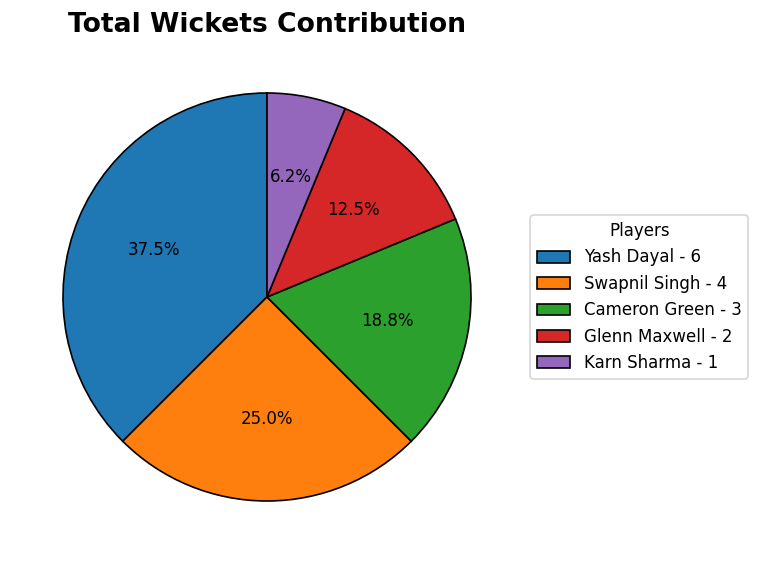

In [ ]:
plt.figure(dpi = 120)
wedges, texts, autotexts= plt.pie(bowling_data["Wickets_Taken"], labels= None, autopct="%1.1f%%", startangle=90, wedgeprops={"edgecolor": "black"})

# Create legend labels with values
legend_labels = [
    f"{player} - {wickets}"
    for player, wickets in zip(bowling_data["Player_Name"], bowling_data["Wickets_Taken"])
]

plt.legend(wedges, legend_labels, title="Players", loc="center left", bbox_to_anchor=(1, 0.5))
plt.title("Total Wickets Contribution", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

Strike-Rate Comparison between Batsmen and All-Rounders

---



In [ ]:
batters_allrounders = done_batting[(done_batting["Role"] == "batsman") | (done_batting["Role"] == "all-rounder")]
strike_rate_diff = ((batters_allrounders.groupby("Player_Name").agg({"Role": "first", "Strike_Rate": "mean", "Runs_Scored": "sum", "Balls_Played":"sum"})).sort_values(by= "Strike_Rate", ascending = False)).round(2).reset_index()
strike_rate_diff["Runs_Scored"] = strike_rate_diff["Runs_Scored"].astype(int)
strike_rate_diff["Balls_Played"] = strike_rate_diff["Balls_Played"].astype(int)
strike_rate_diff.index = strike_rate_diff.index + 1
strike_rate_diff[["Player_Name", "Role", "Strike_Rate"]]

,Player_Name,Role,Strike_Rate
1,Mahipal Lomror,batsman,292.64
2,Anuj Rawat,batsman,275.00
3,Will Jacks,all-rounder,207.67
4,Dinesh Karthik,batsman,202.10
5,Rajat Patidar,batsman,169.56
6,Virat Kohli,batsman,161.78
7,Saurav Chauhan,batsman,150.00
8,Cameron Green,all-rounder,115.18
9,Faf du Plessis,batsman,85.72
10,Glenn Maxwell,all-rounder,60.00


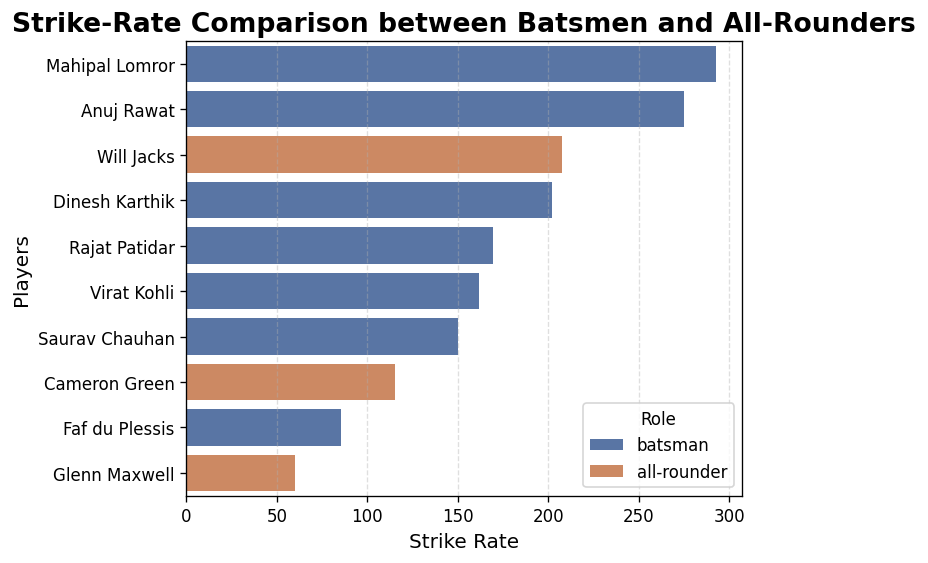

In [ ]:
colors = {"batsman": "#4C72B0", "all-rounder": "#DD8452"}

# Horizontal Barplot

plt.figure(dpi = 120)
sns.barplot(x = strike_rate_diff["Strike_Rate"], y = strike_rate_diff["Player_Name"], hue = strike_rate_diff["Role"], palette= colors)

# Titles and labels

plt.title("Strike-Rate Comparison between Batsmen and All-Rounders", fontsize=16, fontweight="bold")
plt.xlabel("Strike Rate", fontsize = 12)
plt.ylabel("Players", fontsize = 12)

# Gridlines
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Economy-Rate Comparison between Bowlers and All-Rounders


---



In [ ]:
bowlers_allrounders = done_bowling[(done_bowling["Role"] == "bowler") |( done_bowling["Role"] == "all-rounder")]
economy_diff = ((bowlers_allrounders.groupby("Player_Name", as_index = False).agg({"Role": "first", "Economy_Rate":"mean", "Overs_Bowled": "sum", "Runs_Given": "sum"})).sort_values(by = "Economy_Rate")).round(2).reset_index(drop = True)
economy_diff.index = economy_diff.index + 1
economy_diff[["Player_Name", "Role", "Economy_Rate"]]

,Player_Name,Role,Economy_Rate
1,Yash Dayal,bowler,5.58
2,Swapnil Singh,all-rounder,7.00
3,Karn Sharma,bowler,8.62
4,Glenn Maxwell,all-rounder,9.67
5,Cameron Green,all-rounder,10.11
6,Mohammed Siraj,bowler,11.17
7,Lockie Ferguson,bowler,13.00
8,Will Jacks,all-rounder,13.50


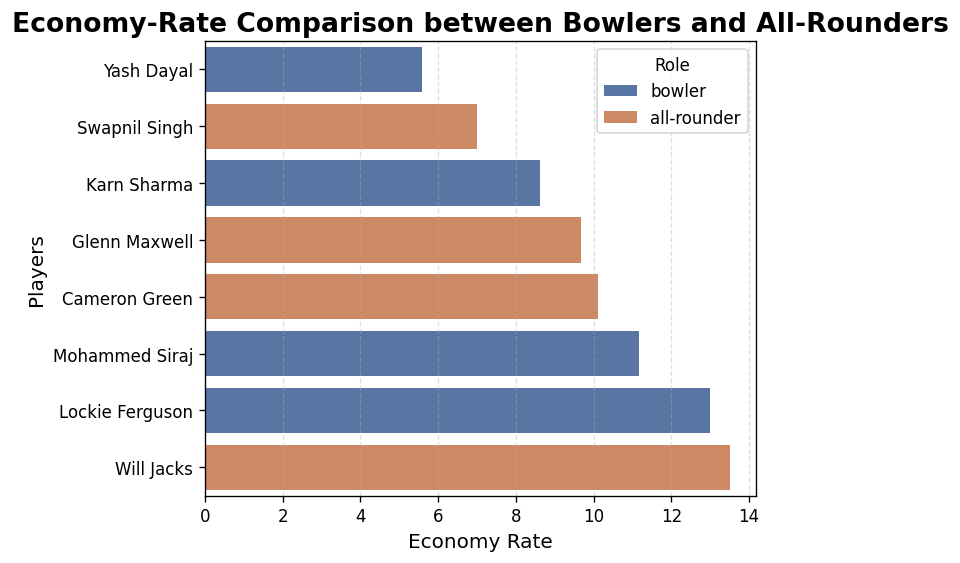

In [ ]:
colors = {"bowler": "#4C72B0", "all-rounder": "#DD8452"}

#Horizontal Barplot
plt.figure(dpi = 120)
sns.barplot(x = economy_diff["Economy_Rate"], y = economy_diff["Player_Name"], hue = economy_diff["Role"], palette= colors)

#Titles and labels

plt.title("Economy-Rate Comparison between Bowlers and All-Rounders", fontsize=16, fontweight="bold")
plt.xlabel("Economy Rate", fontsize = 12)
plt.ylabel("Players", fontsize = 12)

# Gridlines
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Runs Scored Contribution Based on Roles

---




In [ ]:
runs_contribution_by_role = done_batting[done_batting["Runs_Scored"] > 0]
runs_contribution_by_role = (runs_contribution_by_role.groupby("Role", as_index = False)["Runs_Scored"].sum()).sort_values(by= ["Runs_Scored"], ascending = False).reset_index(drop = True)
runs_contribution_by_role["Runs_Scored"] = runs_contribution_by_role["Runs_Scored"].astype(int)
runs_contribution_by_role.index = runs_contribution_by_role.index + 1
runs_contribution_by_role

,Role,Runs_Scored
1,batsman,419
2,all-rounder,164


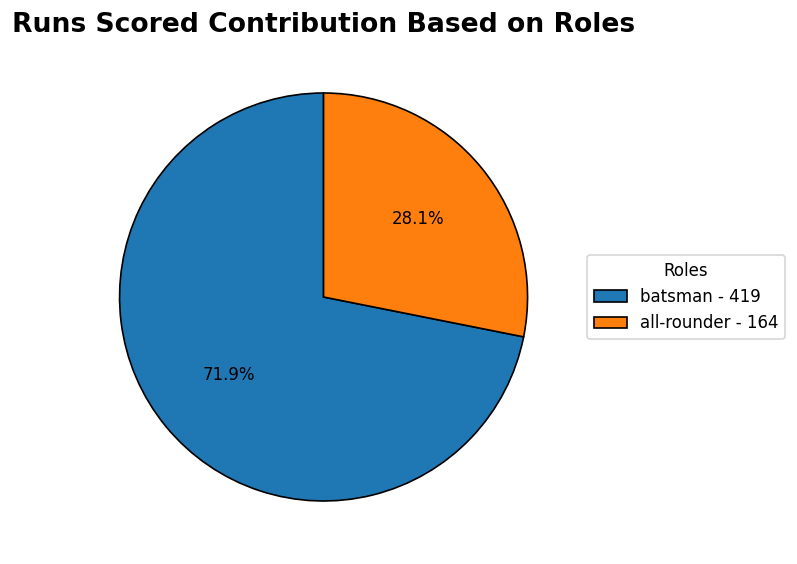

In [ ]:
plt.figure(dpi = 120)
wedges, texts, autotexts= plt.pie(runs_contribution_by_role["Runs_Scored"], labels= None, autopct="%1.1f%%", startangle=90, wedgeprops={"edgecolor": "black"})

# Create legend labels with values
legend_labels = [
    f"{role} - {runs}"
    for role, runs in zip(runs_contribution_by_role["Role"], runs_contribution_by_role["Runs_Scored"])
]

plt.legend(wedges, legend_labels, title="Roles", loc="center left", bbox_to_anchor=(1, 0.5))
plt.title("Runs Scored Contribution Based on Roles", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

Total Wickets Taken Contribution Based on Roles

---

In [ ]:
wickets_contribution_by_role = done_bowling[done_bowling["Wickets_Taken"] > 0]
wickets_contribution_by_role = (wickets_contribution_by_role.groupby("Role", as_index = False)["Wickets_Taken"].sum()).sort_values(by = "Wickets_Taken", ascending = False)
wickets_contribution_by_role["Wickets_Taken"] = wickets_contribution_by_role["Wickets_Taken"].astype(int)
wickets_contribution_by_role.index = wickets_contribution_by_role.index + 1
wickets_contribution_by_role

,Role,Wickets_Taken
1,all-rounder,9
2,bowler,7


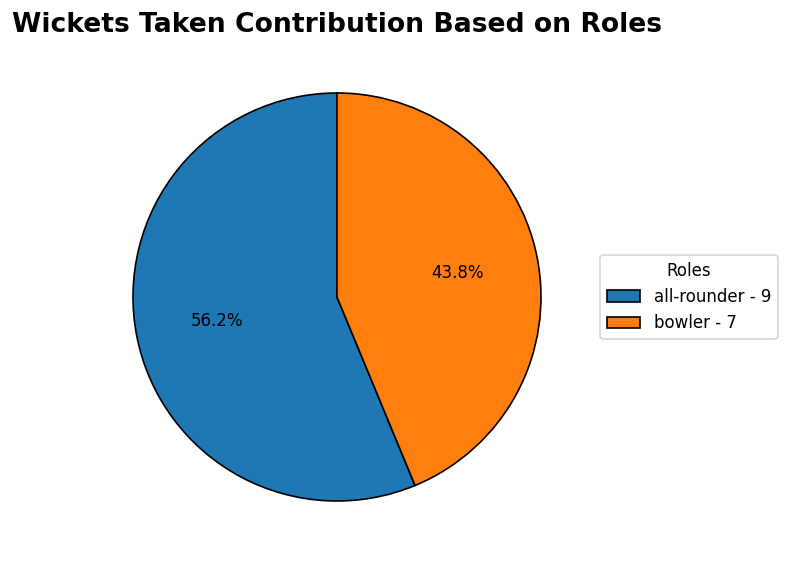

In [ ]:
plt.figure(dpi = 120)
wedges, texts, autotexts= plt.pie(wickets_contribution_by_role["Wickets_Taken"], labels= None, autopct="%1.1f%%", startangle=90, wedgeprops= {"edgecolor" : "black"})
plt.title("Wickets Taken Contribution Based on Roles", fontsize=16, fontweight="bold")

# Create legend labels with values
legend_labels = [
    f"{role} - {wickets}"
    for role, wickets in zip(wickets_contribution_by_role["Role"], wickets_contribution_by_role["Wickets_Taken"])
]
plt.legend(wedges, legend_labels, title="Roles", loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

Players Consitencey in Batting

---



In [ ]:
match_balls_played = df2[df2["Balls_Played"] > 0]
match_runs = match_balls_played.groupby(["Match_No", "Player_Name"])["Runs_Scored"].sum().reset_index()

In [ ]:
if match_balls_played["Match_No"].nunique() > 1:
  batting_consistency = (match_runs.groupby("Player_Name", as_index = False)["Runs_Scored"].agg(["mean", "std","count"])).round(2)
  batting_consistency = batting_consistency[batting_consistency["count"] > 1]
  batting_consistency["Consistency_Score"] = (batting_consistency["mean"] / (batting_consistency["std"] + 1)).round(2)
  batting_consistency = batting_consistency.sort_values(by = "Consistency_Score", ascending = False).reset_index(drop = True)
  batting_consistency.index = batting_consistency.index + 1

else:
  print("Players Consistency in Batting is not applicable for single match dataset")

batting_consistency[["Player_Name", "Consistency_Score"]]

,Player_Name,Consistency_Score
1,Virat Kohli,6.51
2,Dinesh Karthik,3.61
3,Mahipal Lomror,1.47
4,Rajat Patidar,1.34
5,Faf du Plessis,1.15
6,Will Jacks,0.89
7,Cameron Green,0.78


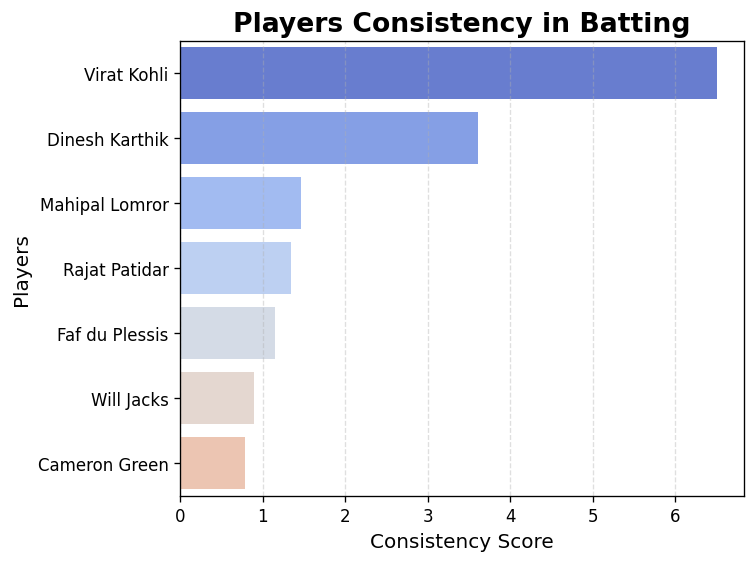

In [ ]:
colors = sns.color_palette("coolwarm", len(runs_difference))

if match_balls_played["Match_No"].nunique() > 1:

  #Horizontal Barplot
  plt.figure(dpi = 120)
  sns.barplot(y = batting_consistency["Player_Name"], x = batting_consistency["Consistency_Score"], palette= colors)

  #Titles and labels
  plt.title("Players Consistency in Batting", fontsize=16, fontweight="bold")
  plt.ylabel("Players", fontsize = 12)
  plt.xlabel("Consistency Score", fontsize = 12)

  # Gridlines
  plt.grid(axis='x', linestyle='--', alpha=0.4)

  plt.tight_layout()
  plt.show()
else:
   print("Players Consistency in Batting is not applicable for single match dataset")

Players Consistency in Bowling

---



In [ ]:
match_overs = df2[df2["Overs_Bowled"] > 0]
match_wickets = match_overs.groupby(["Match_No", "Player_Name"])["Wickets_Taken"].sum().reset_index()

In [ ]:
if match_overs["Match_No"].nunique() > 1:

  bowling_consistency = (match_wickets.groupby("Player_Name", as_index = False)["Wickets_Taken"].agg(["mean", "std","count"])).round(2)
  bowling_consistency = bowling_consistency[bowling_consistency["count"] > 1]
  bowling_consistency["Consistency_Score"] = (bowling_consistency["mean"] / (bowling_consistency["std"] + 1)).round(2)
  bowling_consistency = bowling_consistency.sort_values(by = "Consistency_Score", ascending = False).reset_index(drop = True)
  bowling_consistency.index = bowling_consistency.index + 1

else :
  print("Players Consistency in Bowling in not applicable for single match dataset")
bowling_consistency[["Player_Name", "Consistency_Score"]]

,Player_Name,Consistency_Score
1,Yash Dayal,2.00
2,Swapnil Singh,2.00
3,Cameron Green,0.50
4,Karn Sharma,0.29
5,Mohammed Siraj,0.00


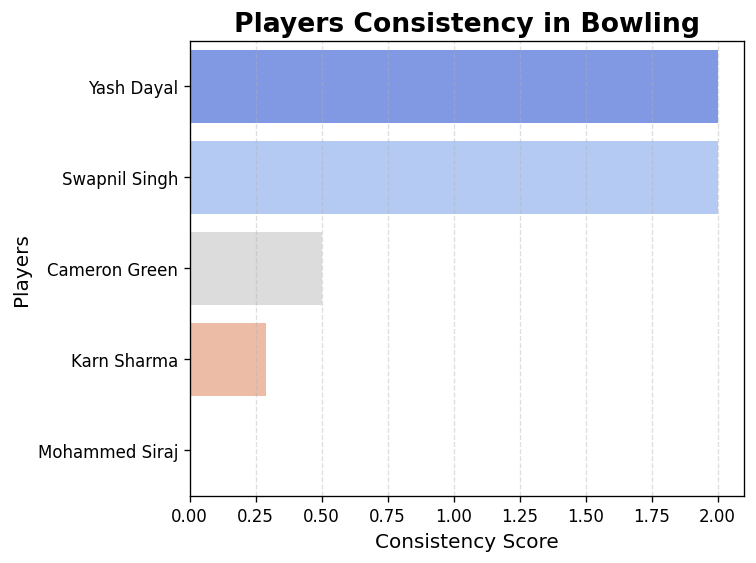

In [ ]:
colors = sns.color_palette("coolwarm", len(bowling_consistency))

if match_overs["Match_No"].nunique() > 1:
  #Horizontal Barplot

  plt.figure(dpi = 120)
  sns.barplot(y = bowling_consistency["Player_Name"], x = bowling_consistency["Consistency_Score"], palette= colors)

  #Titles and labels

  plt.title("Players Consistency in Bowling", fontsize=16, fontweight="bold")
  plt.xlabel("Consistency Score", fontsize = 12)
  plt.ylabel("Players", fontsize = 12)

  # Gridlines
  plt.grid(axis='x', linestyle='--', alpha=0.4)

  plt.tight_layout()
  plt.show()
else:
  print("Players Consistency in Bowling is not applicable for single match dataset")


Average Runs by Batting Order

---



In [ ]:
df2["Batting_Order"] = pd.cut(df2["Batting_Position"],bins = [0,3,7,11], labels=["top","middle","lower"]).astype(str)
order_runs = df2.groupby(df2["Batting_Order"], as_index= False)["Runs_Scored"].sum().sort_values(by = "Runs_Scored", ascending = False).reset_index(drop = True)
order_runs["Average_Runs_Scored"] = order_runs["Runs_Scored"]
order_runs = order_runs.drop("Runs_Scored", axis = 1)
order_runs.index += 1
order_runs

,Batting_Order,Average_Runs_Scored
1,top,366.0
2,middle,197.0
3,lower,20.0


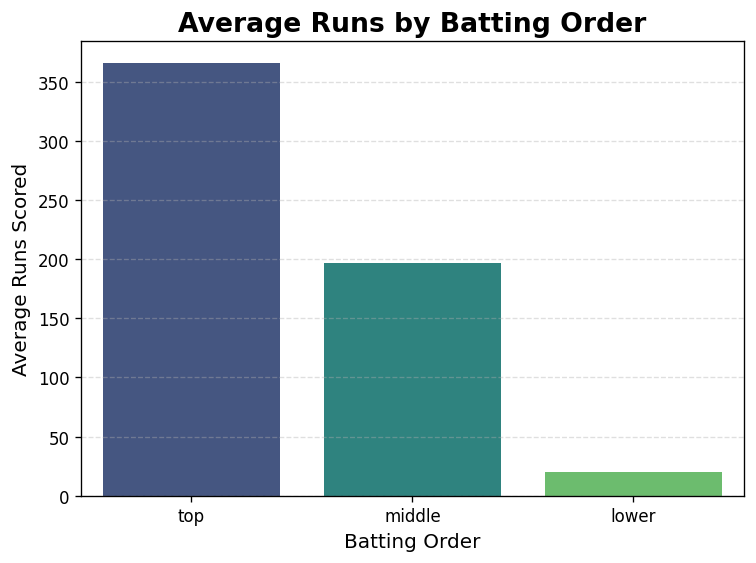

In [ ]:
if ( (df2["Match_No"].nunique()) > 1 ):

  plt.figure(dpi=120)

  sns.barplot(x= order_runs["Batting_Order"], y= order_runs["Average_Runs_Scored"], palette = "viridis")

  plt.title("Average Runs by Batting Order", fontsize = 16, fontweight = "bold")
  plt.xlabel("Batting Order", fontsize = 12)
  plt.ylabel("Average Runs Scored", fontsize = 12)

  plt.grid(axis='y', linestyle='--', alpha=0.4)

  plt.tight_layout()
  plt.show()
else :
  print("Average Runs by Batting Order is not applicable for single match")

Phase wise Wickets Lost breakdown

---



In [ ]:
wickets_df = df2[df2["Was_Out"] == True].copy()
wickets_df["Out_Over"] = pd.to_numeric(wickets_df["Out_Over"], errors="coerce")
def assign_phase(over):
    if over <= 6:
        return "Powerplay"
    elif over <= 15:
        return "Middle Overs"
    else:
        return "Death Overs"

wickets_df["Wicket_Phase"] = wickets_df["Out_Over"].apply(assign_phase)

phase_wickets = (wickets_df.groupby("Wicket_Phase")["Player_Name"].size().reindex(["Powerplay", "Middle Overs", "Death Overs"])).reset_index(name="Wickets_Lost").sort_values(by = "Wickets_Lost", ascending = False)
phase_wickets

,Wicket_Phase,Wickets_Lost
2,Death Overs,6
0,Powerplay,4
1,Middle Overs,2


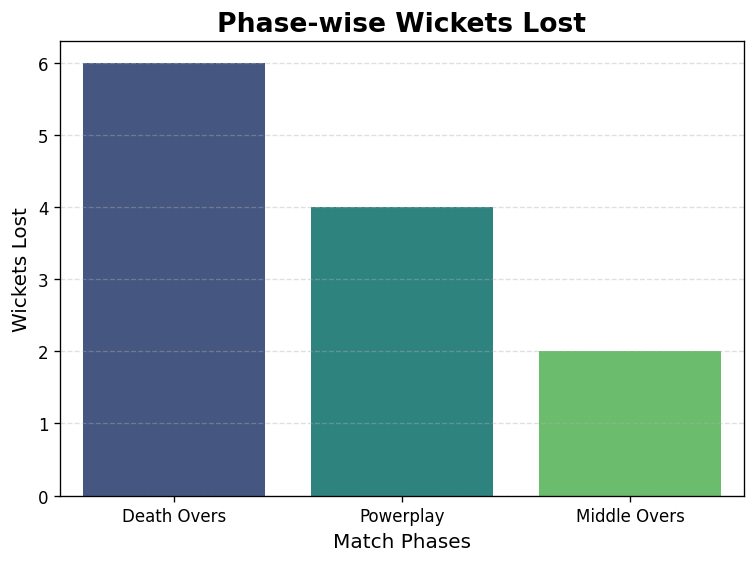

In [ ]:
plt.figure(dpi = 120)
sns.barplot(x=phase_wickets["Wicket_Phase"],y=phase_wickets["Wickets_Lost"], palette = "viridis")

plt.title("Phase-wise Wickets Lost", fontsize = 16, fontweight = "bold")
plt.xlabel("Match Phases", fontsize = 12)
plt.ylabel("Wickets Lost", fontsize = 12)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Player's Total Runs in Each Match

---



In [ ]:
if done_batting["Match_No"].nunique() > 1:
  players_list = done_batting["Player_Name"].unique().tolist()
  print("Enter the Player's Index to see the Total Runs Scored by that player in each match")
  for index, player in enumerate(players_list) :
    print(f"{index+1} : {player}")
  player_index = int(input("enter your choice : "))
  selected_player = players_list[player_index - 1]
  selected_player_df = done_batting[done_batting["Player_Name"] == selected_player]
  print(f"{selected_player}'s Total Runs in Each Match")
  player_runs = selected_player_df.groupby("Match_No")["Runs_Scored"].sum().reset_index()
  player_runs["Runs_Scored"] =  player_runs["Runs_Scored"].astype(int)
  player_runs.index += 1
  print()
else :
  print("Players Total Runs in Each Match is not applicable for single match dataset.")
player_runs

Enter the Player's Index to see the Total Runs Scored by that player in each match
1 : Virat Kohli
2 : Faf du Plessis
3 : Cameron Green
4 : Rajat Patidar
5 : Glenn Maxwell
6 : Dinesh Karthik
7 : Mahipal Lomror
8 : Saurav Chauhan
9 : Anuj Rawat
10 : Will Jacks
enter your choice : 1
Virat Kohli's Total Runs in Each Match



,Match_No,Runs_Scored
1,1,77
2,2,92
3,3,70


Enter the Player's Index to see the Total Runs Scored by that player in each match
1 : Virat Kohli
2 : Faf du Plessis
3 : Cameron Green
4 : Rajat Patidar
5 : Glenn Maxwell
6 : Dinesh Karthik
7 : Mahipal Lomror
8 : Saurav Chauhan
9 : Anuj Rawat
10 : Will Jacks
enter your choice : 3
Cameron Green's Total Runs in Each Match



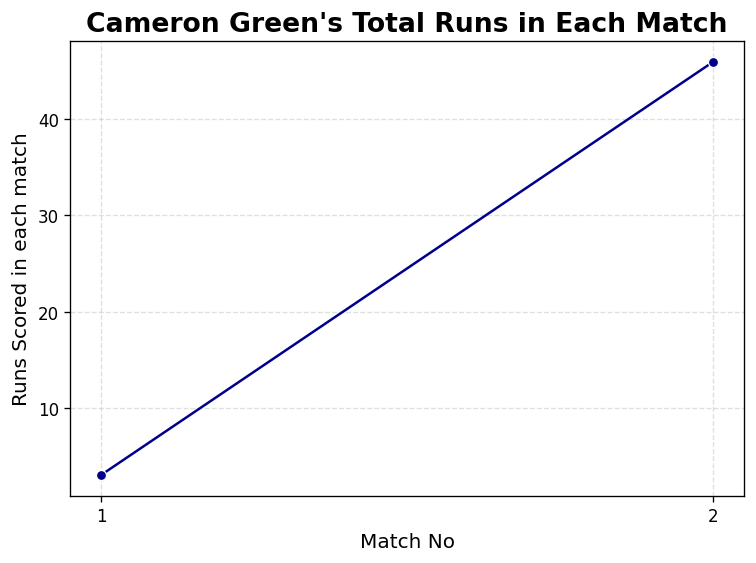

In [ ]:
if done_batting["Match_No"].nunique() > 1:
  players_list = done_batting["Player_Name"].unique().tolist()
  print("Enter the Player's Index to see the Total Runs Scored by that player in each match")
  for index, player in enumerate(players_list) :
    print(f"{index+1} : {player}")
  player_index = int(input("enter your choice : "))
  selected_player = players_list[player_index - 1]
  selected_player_df = done_batting[done_batting["Player_Name"] == selected_player]
  print(f"{selected_player}'s Total Runs in Each Match")
  player_runs = selected_player_df.groupby("Match_No")["Runs_Scored"].sum().reset_index()
  print()

  x_vals = player_runs["Match_No"].astype(int)
  y_vals = player_runs["Runs_Scored"]

  plt.figure(dpi = 120)
  sns.lineplot(x=x_vals, y=y_vals, marker="o", color = "darkblue")

  plt.xticks(range(min(x_vals), max(x_vals)+1))
  plt.title(f"{selected_player}'s Total Runs in Each Match", fontsize = 16, fontweight = "bold")
  plt.xlabel("Match No", fontsize = 12)
  plt.ylabel("Runs Scored in each match", fontsize = 12)

  plt.grid(linestyle='--', alpha=0.4)

  plt.tight_layout()
  plt.show()

Player's Total Wickets in Each Match

---



In [ ]:
if done_bowling["Match_No"].nunique() > 1:
  players_list_bowl = done_bowling["Player_Name"].unique().tolist()
  print("Enter the Player's Index to see the Total Wickets taken by that player in each match")
  for index, player in enumerate(players_list_bowl) :
    print(f"{index+1} : {player}")
  player_index_bowl = int(input("enter your choice : "))
  selected_player_bowl = players_list_bowl[player_index_bowl - 1]
  selected_player_bowl_df = done_bowling[done_bowling["Player_Name"] == selected_player_bowl]
  print(f"{selected_player_bowl}'s Total Wickets in Each Match")
  player_wickets = selected_player_bowl_df.groupby("Match_No")["Wickets_Taken"].sum().reset_index()
  player_wickets["Wickets_Taken"] = player_wickets["Wickets_Taken"].astype(int)
  player_wickets.index += 1
  print()
else :
  print("Player's Total Wickets in Each Match is not applicable for single match dataset.")
player_wickets

Enter the Player's Index to see the Total Wickets taken by that player in each match
1 : Cameron Green
2 : Glenn Maxwell
3 : Mohammed Siraj
4 : Yash Dayal
5 : Will Jacks
6 : Swapnil Singh
7 : Karn Sharma
8 : Lockie Ferguson
enter your choice : 1
Cameron Green's Total Wickets in Each Match



,Match_No,Wickets_Taken
1,1,0
2,2,2
3,3,1


Enter the Player's Index to see the Total Wickets taken by that player in each match
1 : Cameron Green
2 : Glenn Maxwell
3 : Mohammed Siraj
4 : Yash Dayal
5 : Will Jacks
6 : Swapnil Singh
7 : Karn Sharma
8 : Lockie Ferguson
enter your choice : 1
Cameron Green's Total Wickets in Each Match



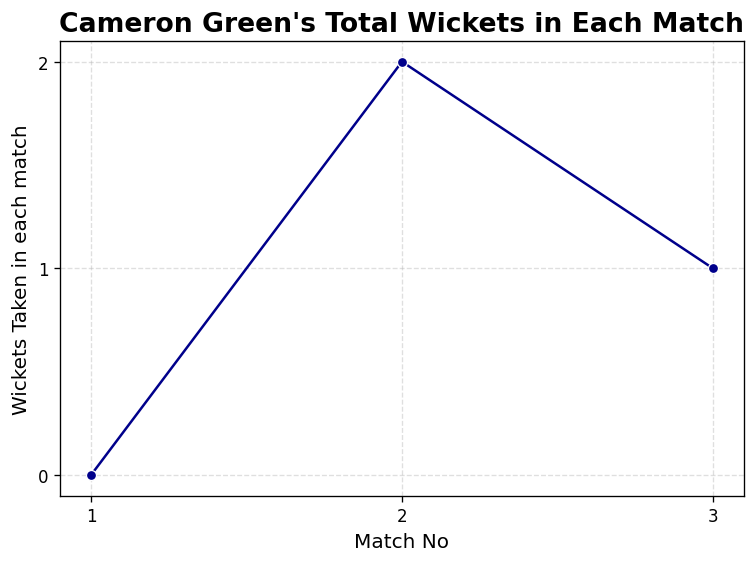

In [ ]:
if done_bowling["Match_No"].nunique() > 1:
    players_list_bowl = done_bowling["Player_Name"].unique().tolist()
    print("Enter the Player's Index to see the Total Wickets taken by that player in each match")

    for index, player in enumerate(players_list_bowl):
        print(f"{index+1} : {player}")
    player_index_bowl = int(input("enter your choice : "))
    selected_player_bowl = players_list_bowl[player_index_bowl - 1]
    selected_player_bowl_df = done_bowling[done_bowling["Player_Name"] == selected_player_bowl]
    print(f"{selected_player_bowl}'s Total Wickets in Each Match")
    print()
    player_wickets = (selected_player_bowl_df.groupby("Match_No")["Wickets_Taken"].sum().reset_index().sort_values("Match_No"))

    x_vals = player_wickets["Match_No"].astype(int)
    y_vals = player_wickets["Wickets_Taken"].astype(int)

    plt.figure(dpi=120)
    sns.lineplot(x=x_vals, y=y_vals, marker="o", color = "darkblue")

    plt.xticks(range(min(x_vals), max(x_vals) + 1))
    plt.yticks(range(min(y_vals), max(y_vals) + 1))

    plt.title(f"{selected_player_bowl}'s Total Wickets in Each Match", fontsize = 16, fontweight = "bold")
    plt.xlabel("Match No", fontsize = 12)
    plt.ylabel("Wickets Taken in each match", fontsize = 12)

    plt.grid(linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

else:
    print("Player's Total Wickets in Each Match is not applicable for single match dataset.")


***Summary***

In [ ]:
print(f"1. {runs_difference.iloc[0]["Player_Name"]} is the highest runs scorer and has scored {runs_difference.iloc[0]["Runs_Scored"]} runs ")
print()
print(f"2. {bowling_diff.iloc[0]["Player_Name"]} is the highest wicket taker and has took {bowling_diff.iloc[0]["Wickets_Taken"]} wickets")
print()
print(f"3. {strike_rate_diff.iloc[0]["Player_Name"]} has the highest strike rate of {strike_rate_diff.iloc[0]["Strike_Rate"]}")
print()
print(f"4. {economy_diff.iloc[0]["Player_Name"]} has the best bowling economy rate of {economy_diff.iloc[0]["Economy_Rate"]}")
print()
print(f"5. {runs_contribution_by_role.iloc[0]["Role"]} are the highest contributors in scoring total runs by scoring {runs_contribution_by_role.iloc[0]["Runs_Scored"]} runs followed by {runs_contribution_by_role.iloc[1]["Role"]} who have scored a total of {runs_contribution_by_role.iloc[1]["Runs_Scored"]} runs")
print()
print(f"6. {wickets_contribution_by_role.iloc[0]["Role"]}s are the highest contributors in taking total wickets by taking {wickets_contribution_by_role.iloc[0]["Wickets_Taken"]} wickets followed by {wickets_contribution_by_role.iloc[1]["Role"]}s who have taken a total of {wickets_contribution_by_role.iloc[1]["Wickets_Taken"]} wickets")
print()
print(f"7. {order_runs.iloc[0]["Batting_Order"]} order is the strongest order in scoring total runs followed by {order_runs.iloc[1]["Batting_Order"]} order")
print()
print(f"8. Our team has lost most of the wickets in {phase_wickets.iloc[0]["Wicket_Phase"]} with the total of {phase_wickets.iloc[0]["Wickets_Lost"]} wickets lost")

1. Virat Kohli is the highest runs scorer and has scored 239 runs 

2. Yash Dayal is the highest wicket taker and has took 6 wickets

3. Mahipal Lomror has the highest strike rate of 292.64

4. Yash Dayal has the best bowling economy rate of 5.58

5. batsman are the highest contributors in scoring total runs by scoring 419 runs followed by all-rounder who have scored a total of 164 runs

6. all-rounders are the highest contributors in taking total wickets by taking 9 wickets followed by bowlers who have taken a total of 7 wickets

7. top order is the strongest order in scoring total runs followed by middle order

8. Our team has lost most of the wickets in Death Overs with the total of 6 wickets lost
